1. Write a program to generate and plot histograms for grayscale and color images. 

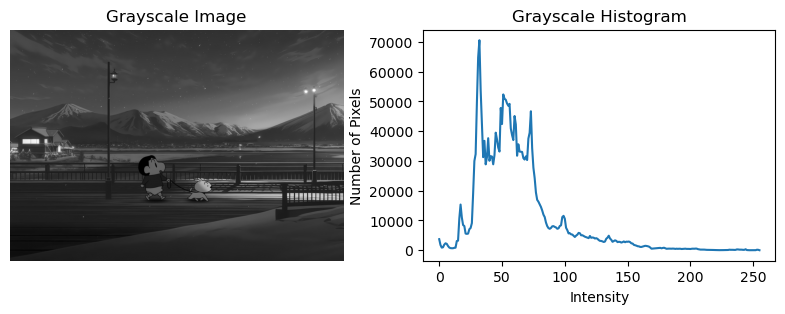

In [18]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread("wallpaper.jpg", cv2.IMREAD_GRAYSCALE)
hist = cv2.calcHist([img], [0], None, [256], [0, 256])
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.plot(hist)
plt.title("Grayscale Histogram")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.show()

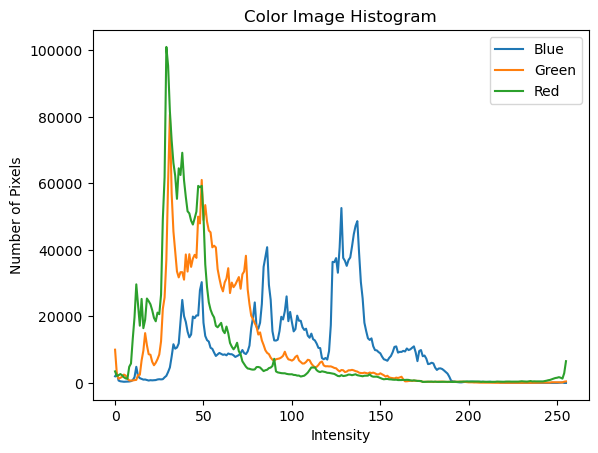

In [8]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread("wallpaper.jpg")
blue = cv2.calcHist([img], [0], None, [256], [0, 256])
green = cv2.calcHist([img], [1], None, [256], [0, 256])
red = cv2.calcHist([img], [2], None, [256], [0, 256])
plt.plot(blue, label="Blue")
plt.plot(green, label="Green")
plt.plot(red, label="Red")
plt.title("Color Image Histogram")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.legend()
plt.show()

2. Write a program to enhance an image using contrast stretching with given parameters r_1=110, r_2=158, s_1=95, and s_2=185. using alphla beta and gama

Alpha = 0.8636363636363636
Beta = 1.875
Gamma = 0.7216494845360825


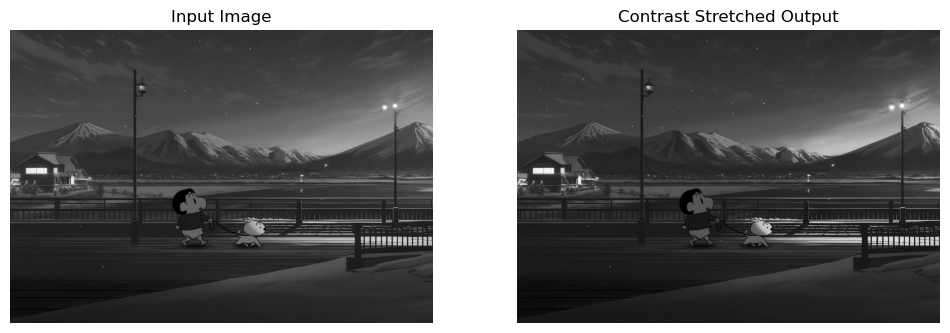

True

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread("wallpaper.jpg", cv2.IMREAD_GRAYSCALE)
r1 = 110
r2 = 158
s1 = 95
s2 = 185
L = 256
alpha = s1 / r1
beta = (s2 - s1) / (r2 - r1)
gamma = (L - 1 - s2) / (L - 1 - r2)
print("Alpha =", alpha)
print("Beta =", beta)
print("Gamma =", gamma)
output = np.zeros_like(img)
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        r = img[i, j]
        if r <= r1:
            s = alpha * r
        elif r <= r2:
            s = beta * (r - r1) + s1
        else:
            s = gamma * (r - r2) + s2
        output[i, j] = np.clip(s, 0, 255)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Input Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(output, cmap="gray")
plt.title("Contrast Stretched Output")
plt.axis("off")
plt.show()
cv2.imwrite("contrast_stretched.jpg", output)